In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
import matplotlib.pyplot as plt


# Suppress warnings
warnings.filterwarnings('ignore')

# **What is Regression?**
Regression is a statistical technique used to estimate the relationship between a dependent variable (output) and one or more independent variables (inputs), with the goal of predicting or explaining the dependent variable.

Multiple regression models the relationship between two or more independent variables and one dependent variable.


Suppose your car:
- Gets 30 miles per gallon (mpg)
- Gas costs $4 per gallon

We want to model the total cost of gas (y) for driving x miles.

The general equation of a linear relationship is:

$y = mx + b$

where,
- y is the dependent variable (output), also called response variable
- x is the independent variable (input); also called explanatory or predictor variable
- m is the slope (rate of change of y with respect to x),
- b is the y-intercept (the value of y when x = 0).

In this example,
- y = total gas cost in dollars (dependent variable)
- x = miles driven (independent variable)
- Slope m = 0.133 dollars per mile (gas cost per mile)

$y = \frac{4}{30}x = 0.133x$

$y = 0.133x$

In [11]:
x = list(range(1,100))
y = [i * 0.133 for i in x]

In [12]:
df = pd.DataFrame({"Miles driven":x,
                   "Total gas cost ($)":y})
df.head()

,Miles driven,Total gas cost ($)
0,1,0.133
1,2,0.266
2,3,0.399
3,4,0.532
4,5,0.665


### **Slope and Gas Cost per Mile**

The slope $m$ represents the cost incurred for every additional mile driven.

It is derived as follows:
$$\text{Cost} = \text{Gallons Used} \times \text{Price per Gallon}$$

Since $\text{Gallons Used} = \frac{\text{Miles Driven}}{\text{MPG}}$, we can substitute:

$$\text{Cost} = \frac{\text{Miles Driven}}{\text{MPG}} \times \text{Price per Gallon}$$

Rearranging to match the linear equation $y = mx$:

$$y = \left( \frac{\text{Price per Gallon}}{\text{MPG}} \right) x$$

So, the slope $m$ is:

$$m = \frac{4}{30} \approx 0.133 \text{ dollars per mile}$$

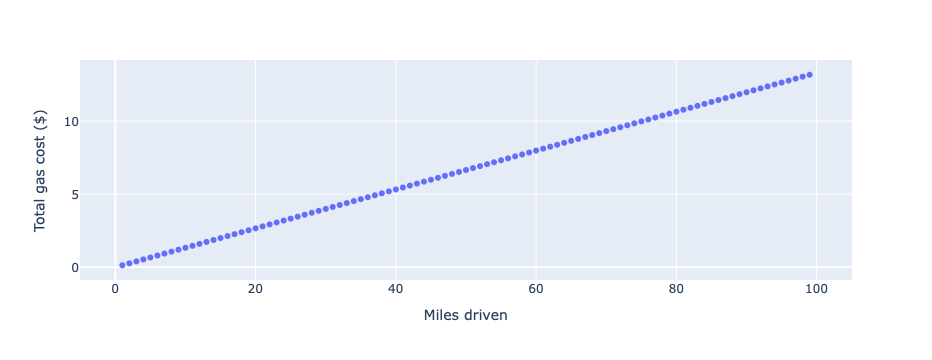

In [13]:
fig = px.scatter(
    df,
    x = "Miles driven",
    y = "Total gas cost ($)",
    labels = {"Miles driven":"Miles driven","Total gas cost ($)":"Total gas cost ($)"}
)
fig.show()

**Is this a downward or upward linear trend?**

# **Possum datasets**

### Possums in Australia and New Guinea

**Description**
Data representing possums in Australia and New Guinea. This is a copy of the data set by the same name in the DAAG package, however, the data set included here includes fewer variables.

**Usage**
possum

**Format**
A data frame with 104 observations on the following 8 variables.

**site**
The site number where the possum was trapped.

**pop**
Population, either Vic (Victoria) or other (New South Wales or Queensland).

**sex**
Gender, either m (male) or f (female).

**age**
Age.

**head_l**
Head length, in mm.

**skull_w**
Skull width, in mm.

**total_l**
Total length, in cm.

**tail_l**
Tail length, in cm.

**Source**
Lindenmayer, D. B., Viggers, K. L., Cunningham, R. B., and Donnelly, C. F. 1995. Morphological variation among columns of the mountain brushtail possum, Trichosurus caninus Ogilby (Phalangeridae: Marsupiala). Australian Journal of Zoology 43: 449-458.

> **Note:**
> You might encounter issues when trying to download the CSV file directly from the browser. A **403 Forbidden** error typically means the server is refusing the request—often due to missing authentication or because it detects the request is coming from a non-browser source.  
> **Solution:** Pass a User-Agent header in the request to mimic a browser.

In [14]:
import pandas as pd
import requests
from io import StringIO

url = "https://www.openintro.org/data/csv/possum.csv"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)
response.raise_for_status() # Raise an exception for bad status codes
df = pd.read_csv(StringIO(response.text))

In [15]:
df.head()

,site,pop,sex,age,head_l,skull_w,total_l,tail_l
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0


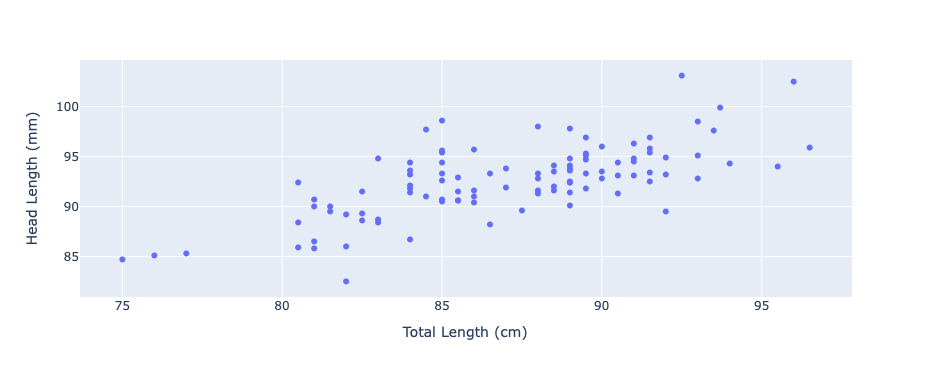

In [16]:
fig = px.scatter(
    df,
    x = "total_l",
    y = "head_l",
    labels = {"total_l":"Total Length (cm)","head_l":"Head Length (mm)"}
)
fig.show()

In [17]:
# Fit linear regression line (y = mx + b)
m, b = np.polyfit(df["total_l"], df["head_l"], 1)
print(m,b)
df["y_pred"] = m * df["total_l"] + b

0.5729012843381799 42.70979314896378


In [18]:
df.head()

,site,pop,sex,age,head_l,skull_w,total_l,tail_l,y_pred
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0,93.698007
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5,95.130261
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0,97.421866
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0,95.416711
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0,91.692853


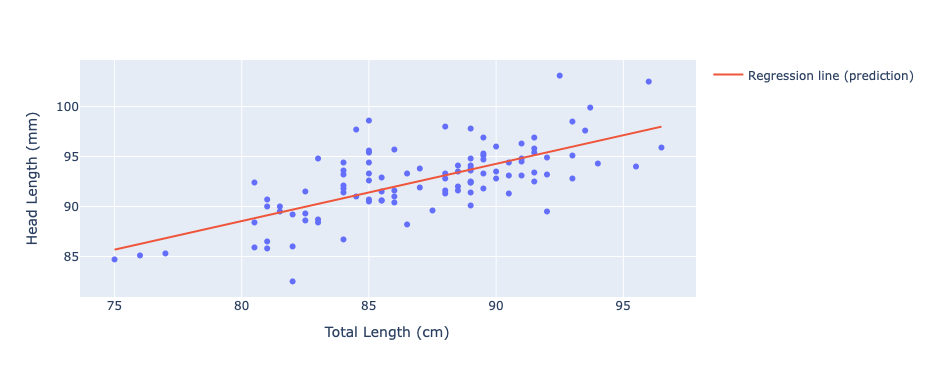

In [19]:
fig = px.scatter(
    df, x = "total_l",
    y = "head_l",
    labels = {"total_l":"Total Length (cm)","head_l":"Head Length (mm)"}
)
fig.add_scatter(x=df["total_l"], y=df["y_pred"], mode="lines",name='Regression line (prediction)')
fig.show()

## **Residuals**
> **Residuals represent the remaining variation in the data after the model has been applied**

$Data = Model Fit + Residual$

Every data point has a residual — the vertical distance between the observed value and the regression line. If the point lies above the line, the residual is positive; if it’s below, the residual is negative. A key goal in choosing a good linear model is to minimize these residuals as much as possible. **The size of a residual is usually discussed in terms of its absolute value**.

For example,
The observed head length of the possum is 84.7 mm when its body length is 75 cm. The model predicts a head length of 85.6 mm, resulting in a residual of –0.9 mm. The negative residual indicates that the linear model overpredicted the head length for this possum.

> **The residual of the ith observation ($x_i$,$y_i$) is the difference of the observed response ($y_i$) and the response we would predict based on the model fit ($ \widehat{y}_i $):**
$$e_i = y_i − \widehat{y}_i $$

## **Correlation**
> **Correlation, which always takes values between -1 and 1, describes the strength of the linear relationship between two variables. We denote the correlation by R.**

R = near +1: The relationship is strong and positive.  
R = near -1: The relationship is strong and negative.  
R = near 0: No apparent linear relationship between the variables.  

Correlation (R) can be calculated using numpy (np.corrcoef) or using pandas df.corr(). See example below.

In [20]:
#np.corrcoef(df['total_l'],df['head_l'])[0,1] # Calculate R using numpy

In [21]:
df['total_l'].corr(df['head_l']) # Calculate R using pandas

np.float64(0.6910936973935056)

## **Ordinary Least Square Regression Results**

The regression results (see below) gives lots of information about the model including the slope and the intercept.

In [22]:
import statsmodels.api as sm
X = sm.add_constant(df["total_l"])  # adds intercept
model = sm.OLS(df["head_l"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 head_l   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     93.26
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           4.68e-16
Time:                        17:16:51   Log-Likelihood:                -245.75
No. Observations:                 104   AIC:                             495.5
Df Residuals:                     102   BIC:                             500.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.7098      5.173      8.257      0.0

Based on the OLS summary, the constant (b) is 42.70 and the slope (m) is 0.57.
The linear regression will look like:

$\widehat{Head Length} = 42.70 + 0.57 \times TotalLength $

### **In some statistic books, the slope m is also represented by $\beta_1$. Why?** ###

In statistics, especially in linear regression, the slope m is often denoted as $\beta_1$ (read as beta one). Here’s how it all fits together:

**Statistical Notation for a Linear Regression Model**

$y = \beta_0 + \beta_1 x + \varepsilon$

| **Symbol**    | **Meaning**                      |
| -----------   | -------------------------------- |
| y             | Dependent variable (output)      |
| x             | Independent variable (input)     |
| $\beta_0$     | Intercept (same as b in algebra) |
| $\beta_1$     | Slope (same as m)                |
| $\varepsilon$ | Error term (random variation)    |

**Compare with Algebra Notation**

| **Algebraic notation** | **Statistical notation**         |
| --------------------           | ----------------------- |
| $y = mx + b$            | $y = \beta_0 + \beta_1 x$ |

**Why use $\beta_1$ instead of m?**.

In regression analysis, we often estimate multiple predictors, like:

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \varepsilon$


So using $\beta_1$, $\beta_2$, $\dots$ helps generalize the model for multiple linear regression, where each $\beta_i$ is the slope for a different variable.

## **Exercise**

1. Choose a dataset you like from https://openintro.org/data/. Identify two variables of interest, explore their relationship visually (e.g., using a scatterplot and draw a regression line), and calculate the correlation between them.
2. Identify a positive, a negative and no-relationship between two variables. You may use the same dataset for both relationships or choose different datasets.

# **Elmhurst College gift aid**

**Description**
A random sample of 50 students gift aid for students at Elmhurst College.

**Usage**
elmhurst

**Format**
A data frame with 50 observations on the following 3 variables.

**family_income**
Family income of the student.

**gift_aid**
Gift aid, in $1000s.

**price_paid**
Price paid by the student (tuition - gift aid).

Source
These data were sampled from a table of data for all freshman from the 2011 class at Elmhurst College that accompanied an article titled What Students Really Pay to Go to College published online by The Chronicle of Higher Education: https://www.chronicle.com/article/what-students-really-pay-to-go-to-college/.

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import requests
from io import StringIO

url = "https://openintro.org/data/csv/elmhurst.csv"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)
response.raise_for_status() # Raise an exception for bad status codes
df_elmhurst = pd.read_csv(StringIO(response.text))

In [ ]:
df_elmhurst.head()

In [ ]:
fig = px.scatter(
    df_elmhurst,
    x = "family_income",
    y = "gift_aid",
    labels = {"family_income":"Family income ($) in k","gift_aid":"Gift aid ($) in k"}
)
fig.show()

In [2]:
# Fit linear regression line (y = mx + b); Finding m & b
m, b = np.polyfit(df_elmhurst["family_income"], df_elmhurst["gift_aid"], 1)
df_elmhurst["y_pred"] = m * df_elmhurst["family_income"] + b    # y_pred (gift aid prediction)

NameError: name 'np' is not defined

In [3]:
fig = px.scatter(
    df_elmhurst,
    x = "family_income",
    y = "gift_aid",
    labels = {"family_income":"Family income ($) in k","gift_aid":"Gift aid ($) in k"}
)
fig.add_scatter(x=df_elmhurst["family_income"], y=df_elmhurst["y_pred"], mode="lines",name='Regression line (prediction)')
fig.show()

NameError: name 'px' is not defined

In [4]:
df_elmhurst.head()

NameError: name 'df_elmhurst' is not defined

### **OLS (Ordinary Least Squares)**

OLS is the most common method for fitting a linear regression model.

It finds the best-fitting line by minimizing the sum of squared errors (residuals) between predicted values and actual data:

$\text{OLS minimizes:} \displaystyle \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

Where:
- $y_i$ = actual value
- $\widehat{y}_i$ = predicted value from the regression line

You can calculate OLS in 3 main ways in Python:

a. Using statsmodels (Statistical modeling library)
b. Using scikit-learn (Machine learning library)
c. Using Matrix Algebra (Manual / NumPy)

> **Due to time constraints, I will be using statsmodels for linear regression. Once you become comfortable with statsmodels, you’ll find it easier to transition to other libraries or apply matrix algebra to compute regression coefficients.**




#### **```sm.ols``` & ```smf.ols```**

There are two functions to perform Ordinary Least Squares (OLS) linear regression in statsmodels. ```sm.OLS``` and ```smf.ols```; but they differ in how you specify your model.

1. sm.OLS — Numeric API (matrix-based)
- Part of statsmodels.api (usually imported as sm)
- You must manually prepare your design matrix (X) and response vector (y)
- Categorical variables must be encoded yourself (e.g., using pd.get_dummies())

2. smf.ols — Formula API (R-style)
- Part of statsmodels.formula.api (usually imported as smf)
- Uses a string-based formula, e.g. 'Y ~ X + C(Z)'
- Automatically handles categorical variables and adds intercept

I have used both functions, as shown below.

In [5]:
import statsmodels.formula.api as smf
model = smf.ols('gift_aid ~ family_income',data=df_elmhurst).fit()
print(model.summary())

NameError: name 'df_elmhurst' is not defined

In [6]:
import statsmodels.api as sm
X = sm.add_constant(df_elmhurst["family_income"])  # adds intercept
model = sm.OLS(df_elmhurst["gift_aid"], X).fit()
print(model.summary())

NameError: name 'df_elmhurst' is not defined

$\widehat{y} = \beta_0 + \beta_1 x + \varepsilon$  
where, constant $\beta_0$ which is also called $b$ in algebaric notation is 24.31, and $\beta_1$ (slope m) is -0.0431; $\widehat{y}$ is a prediction

$\widehat{aid} = 24.31 - 0.0431 \times \text{familyincome}$

**How to read the equation?**  
When family income is 0 (x = 0), the gift aid would be approximately \$24k;

For every 1,000 dollars increase in income, gift aid is reduced by \$43.



**Exercise**

1. At what family income level does gift aid drop to zero?
2. Discuss the limitation exist in this equation.


## **Are variables related? (finding $R$)**

The correlation coefficient is a statistical measure that describes the strength and direction of a relationship between two variables.

There are several ways to calculate correlation between variables, depending on the type of data (e.g. continuous, ordinal, non-linear) and assumptions (e.g. normality). Here are the most common methods:


**Correlation Methods Summary Chart**

| Method                       | Best For                             | Data Type             | Assumptions / Notes                            |
| ---------------------------- | ------------------------------------ | --------------------- | ---------------------------------------------- |
| **Pearson ($r$)**              | Linear relationships                 | Continuous (numeric)  | Assumes normality, linearity, no outliers      |
| **Spearman ($\rho$)**        | Monotonic/ranked relationships       | Ordinal or continuous | Non-parametric, less sensitive to outliers     |
| **Kendall’s Tau ($\tau$)**   | Small samples or ranked data         | Ordinal               | Non-parametric, good for small datasets        |
| **Point-Biserial**           | Continuous vs. binary                | Continuous & binary   | Special case of Pearson                        |
| **Phi ($\phi$) Coefficient** | Two binary variables                 | Binary                | Similar to Pearson for binary/dichotomous data |
| **Partial Correlation**      | Controlling third variable influence | Continuous            | Adjusts for confounding variables              |
| **Distance Correlation**     | Linear and non-linear associations   | Any numeric           | No assumption of linearity                     |



### **Pearson Correlation Coefficient (r)**

Since the topic assumes a linear relationship between two continuous variables, along with normal distribution and no major outliers, the Pearson correlation coefficient is an appropriate choice.

Developed by Karl Pearson, so it's also called the Pearson correlation coefficient. In some books, it is represented by  $r$  or  $R$ . The range is  $−1\le 𝑟 \le 1 $

For example,

r = 0.9 → As one variable increases, the other tends to increase (strong positive).

r = -0.8 → As one variable increases, the other tends to decrease (strong negative).

r ≈ 0 → No consistent pattern.

Here are scatter plots showing different strengths and directions of correlation (R):
- Top Left: Strong positive correlation ($R \approx +0.9$) — points trend upward.
- Top Right: Weak positive correlation ($R \approx +0.5$) — upward trend with more spread.
- Bottom Left: No correlation ($R \approx 0$) — no clear pattern.
- Bottom Right: Strong negative correlation ($R \approx -0.9$) — points trend downward.

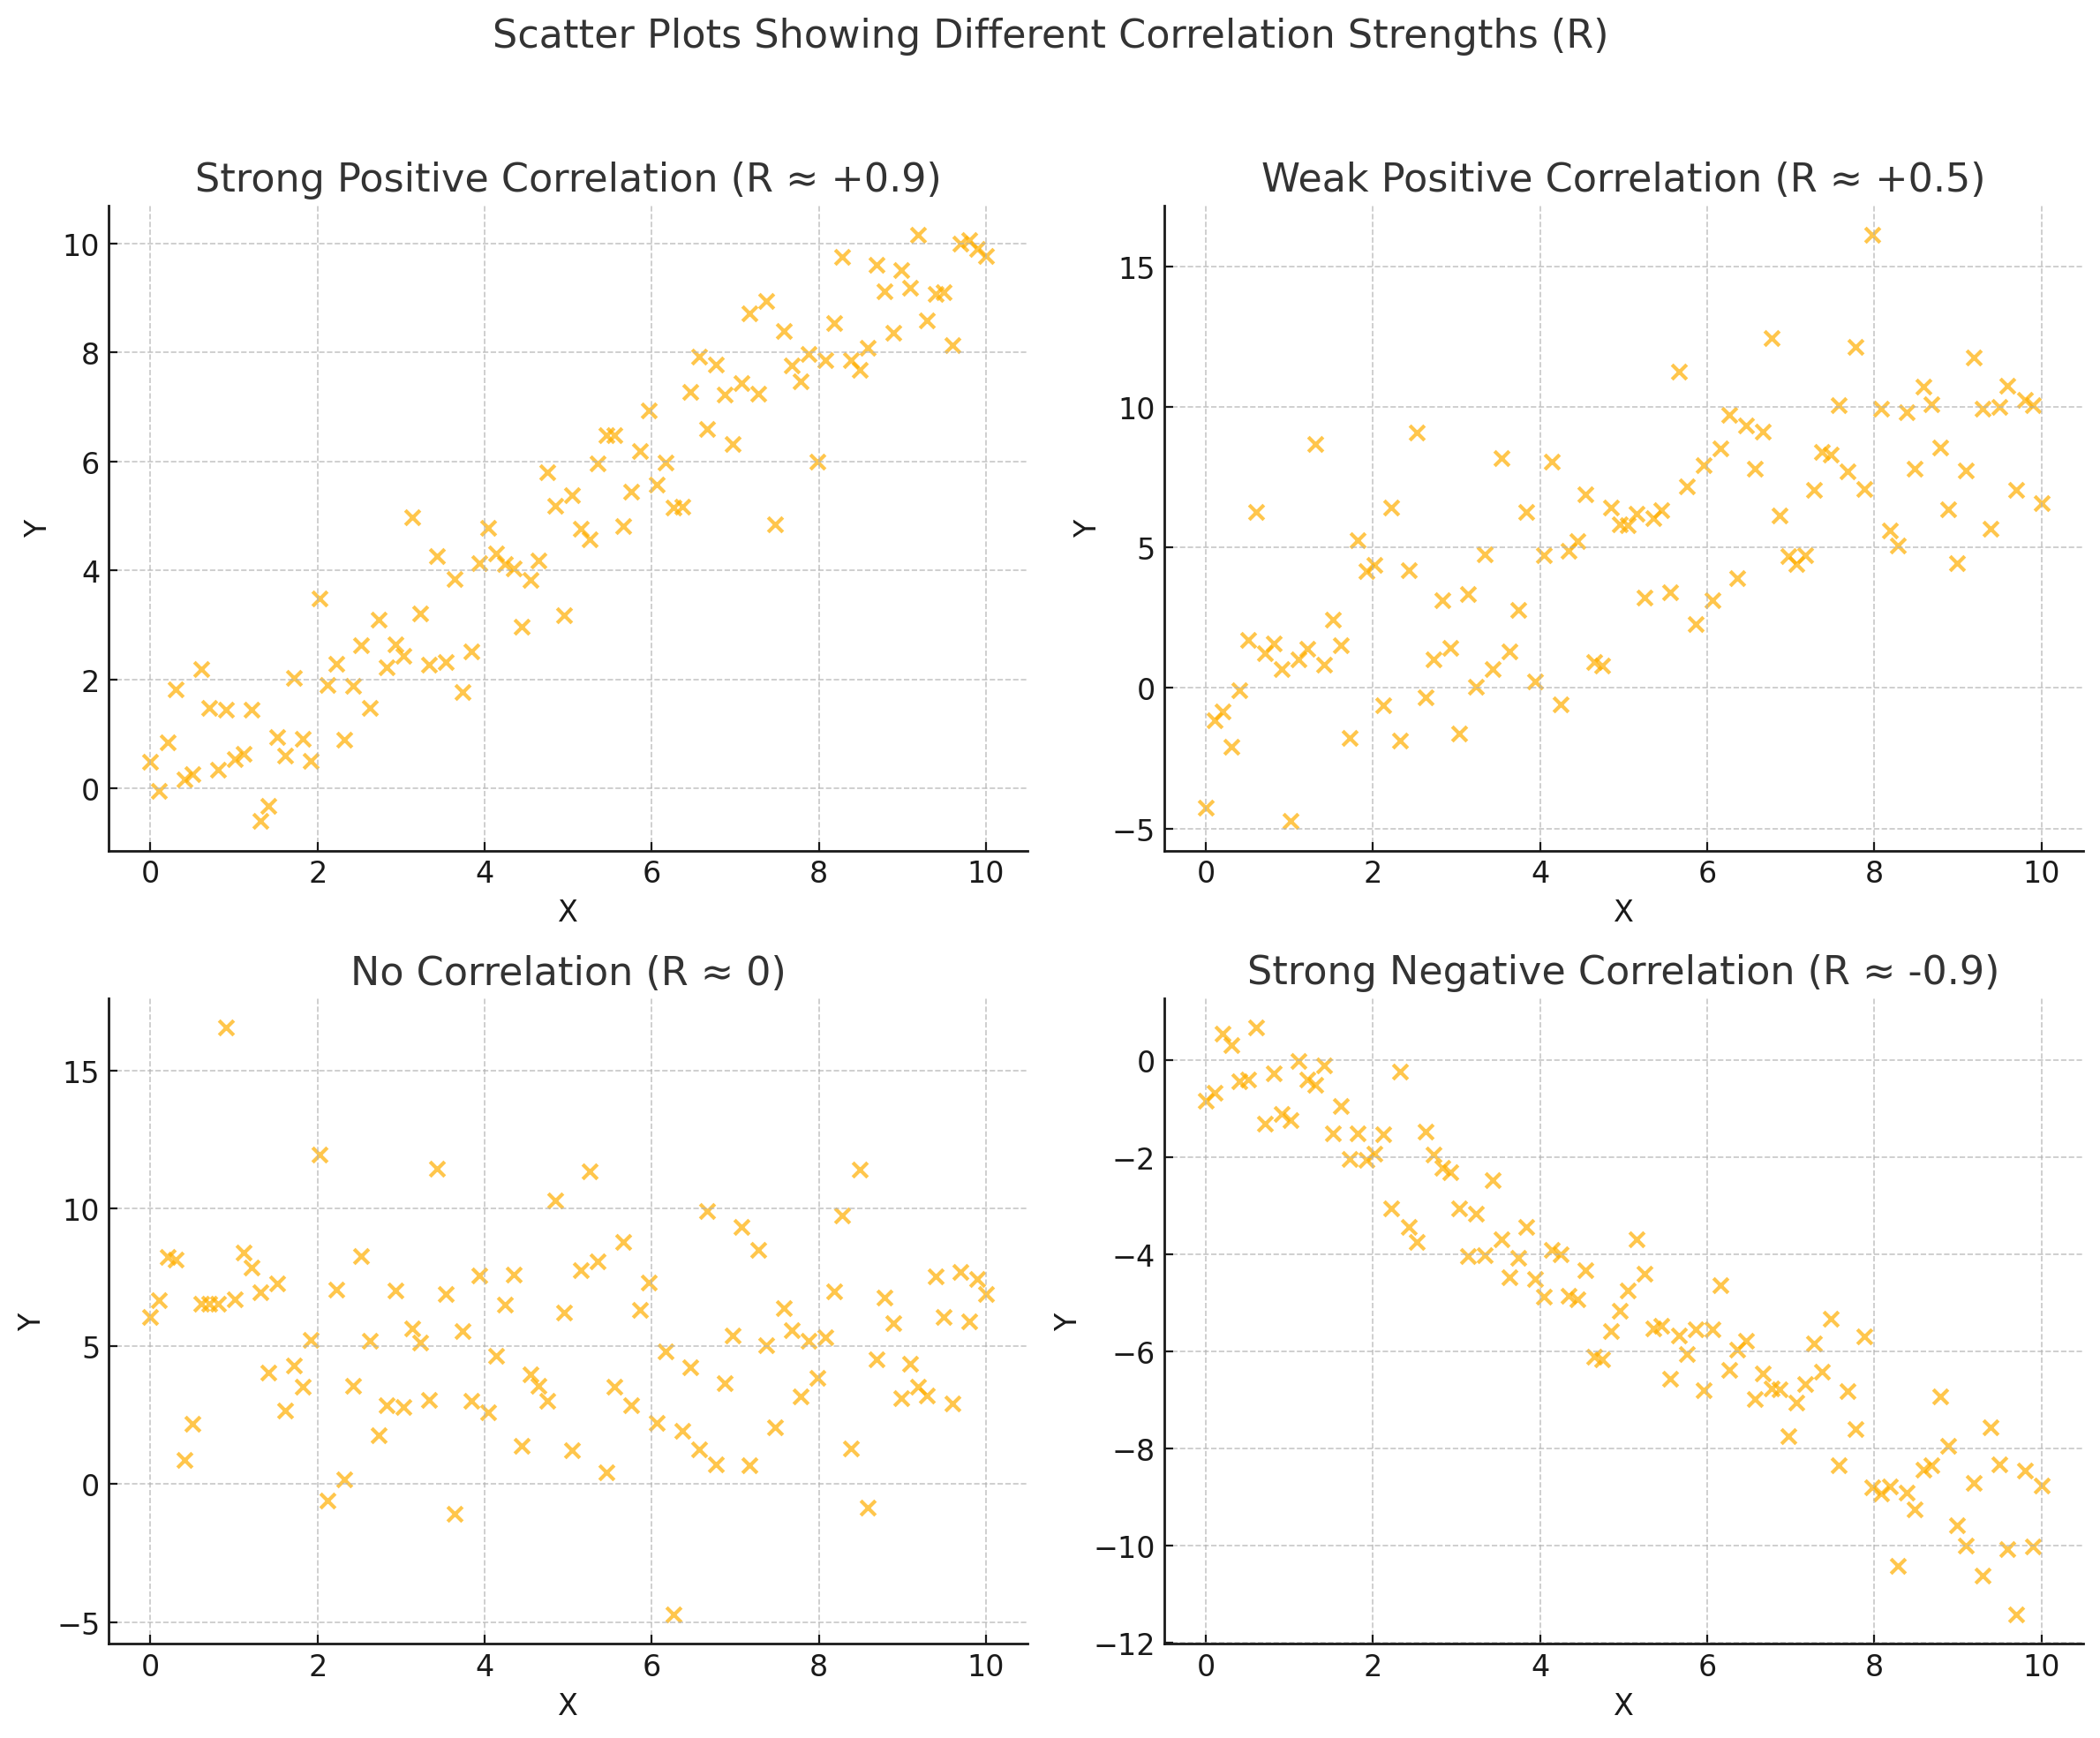

Using the Elmhurst dataset, the correlation between family income & gift aid variables is:

In [7]:
np.corrcoef(df_elmhurst['gift_aid'],df_elmhurst['family_income'])[0,1]

NameError: name 'np' is not defined

Given the R value of -0.49, the two variables exhibit a moderate inverse relationship.

> **Correlation $\ne$ Causation**

> Just because two things move together doesn’t mean one causes the other.


## **How well the model fits the data?**

### **$R^2$ (coefficient of determination)**

R-squared is used to evaluate the goodness-of-fit of a linear model. In other words, how much of the variation in the dependent variable is explained by the independent variable.

Range: 0 to 1 (or 0% to 100%)

For example, if R = -0.49, it means a moderate negative linear relationship — as one variable increases, the other tends to decrease.

$R^2 = (-0.49)^2 = 0.24$

This means that 24% of the variation in the dependent variable can be explained by the independent variable. In other words, about 24% of the variability in aid can be predicted using family income through a linear model.

For example:

| **R Value** | **R² Value** | **What It Means**                 |
| ----------- | ------------ | --------------------------------- |
| 0.9         | 0.81         | 81% of changes in Y are explained |
| 0.5         | 0.25         | 25% explained                     |
| 0.0         | 0.00         | None of the variation explained   |



**Example**

Here are scatter plots with regression lines and $R^2$ values (coefficient of determination):
- $R^2 \approx 0.85$ (Top Left): Strong positive correlation — about 85% of the variance in Y is explained by X.
- $R^2 \approx 0.28$ (Top Right): Weak positive correlation — only 28% of the variation is explained.
- $R^2 \approx 0.00$ (Bottom Left): No correlation — X explains none of the variation in Y.
- $R^2 \approx 0.86$ (Bottom Right): Strong negative correlation — 86% of the variation is explained, but with a negative trend.

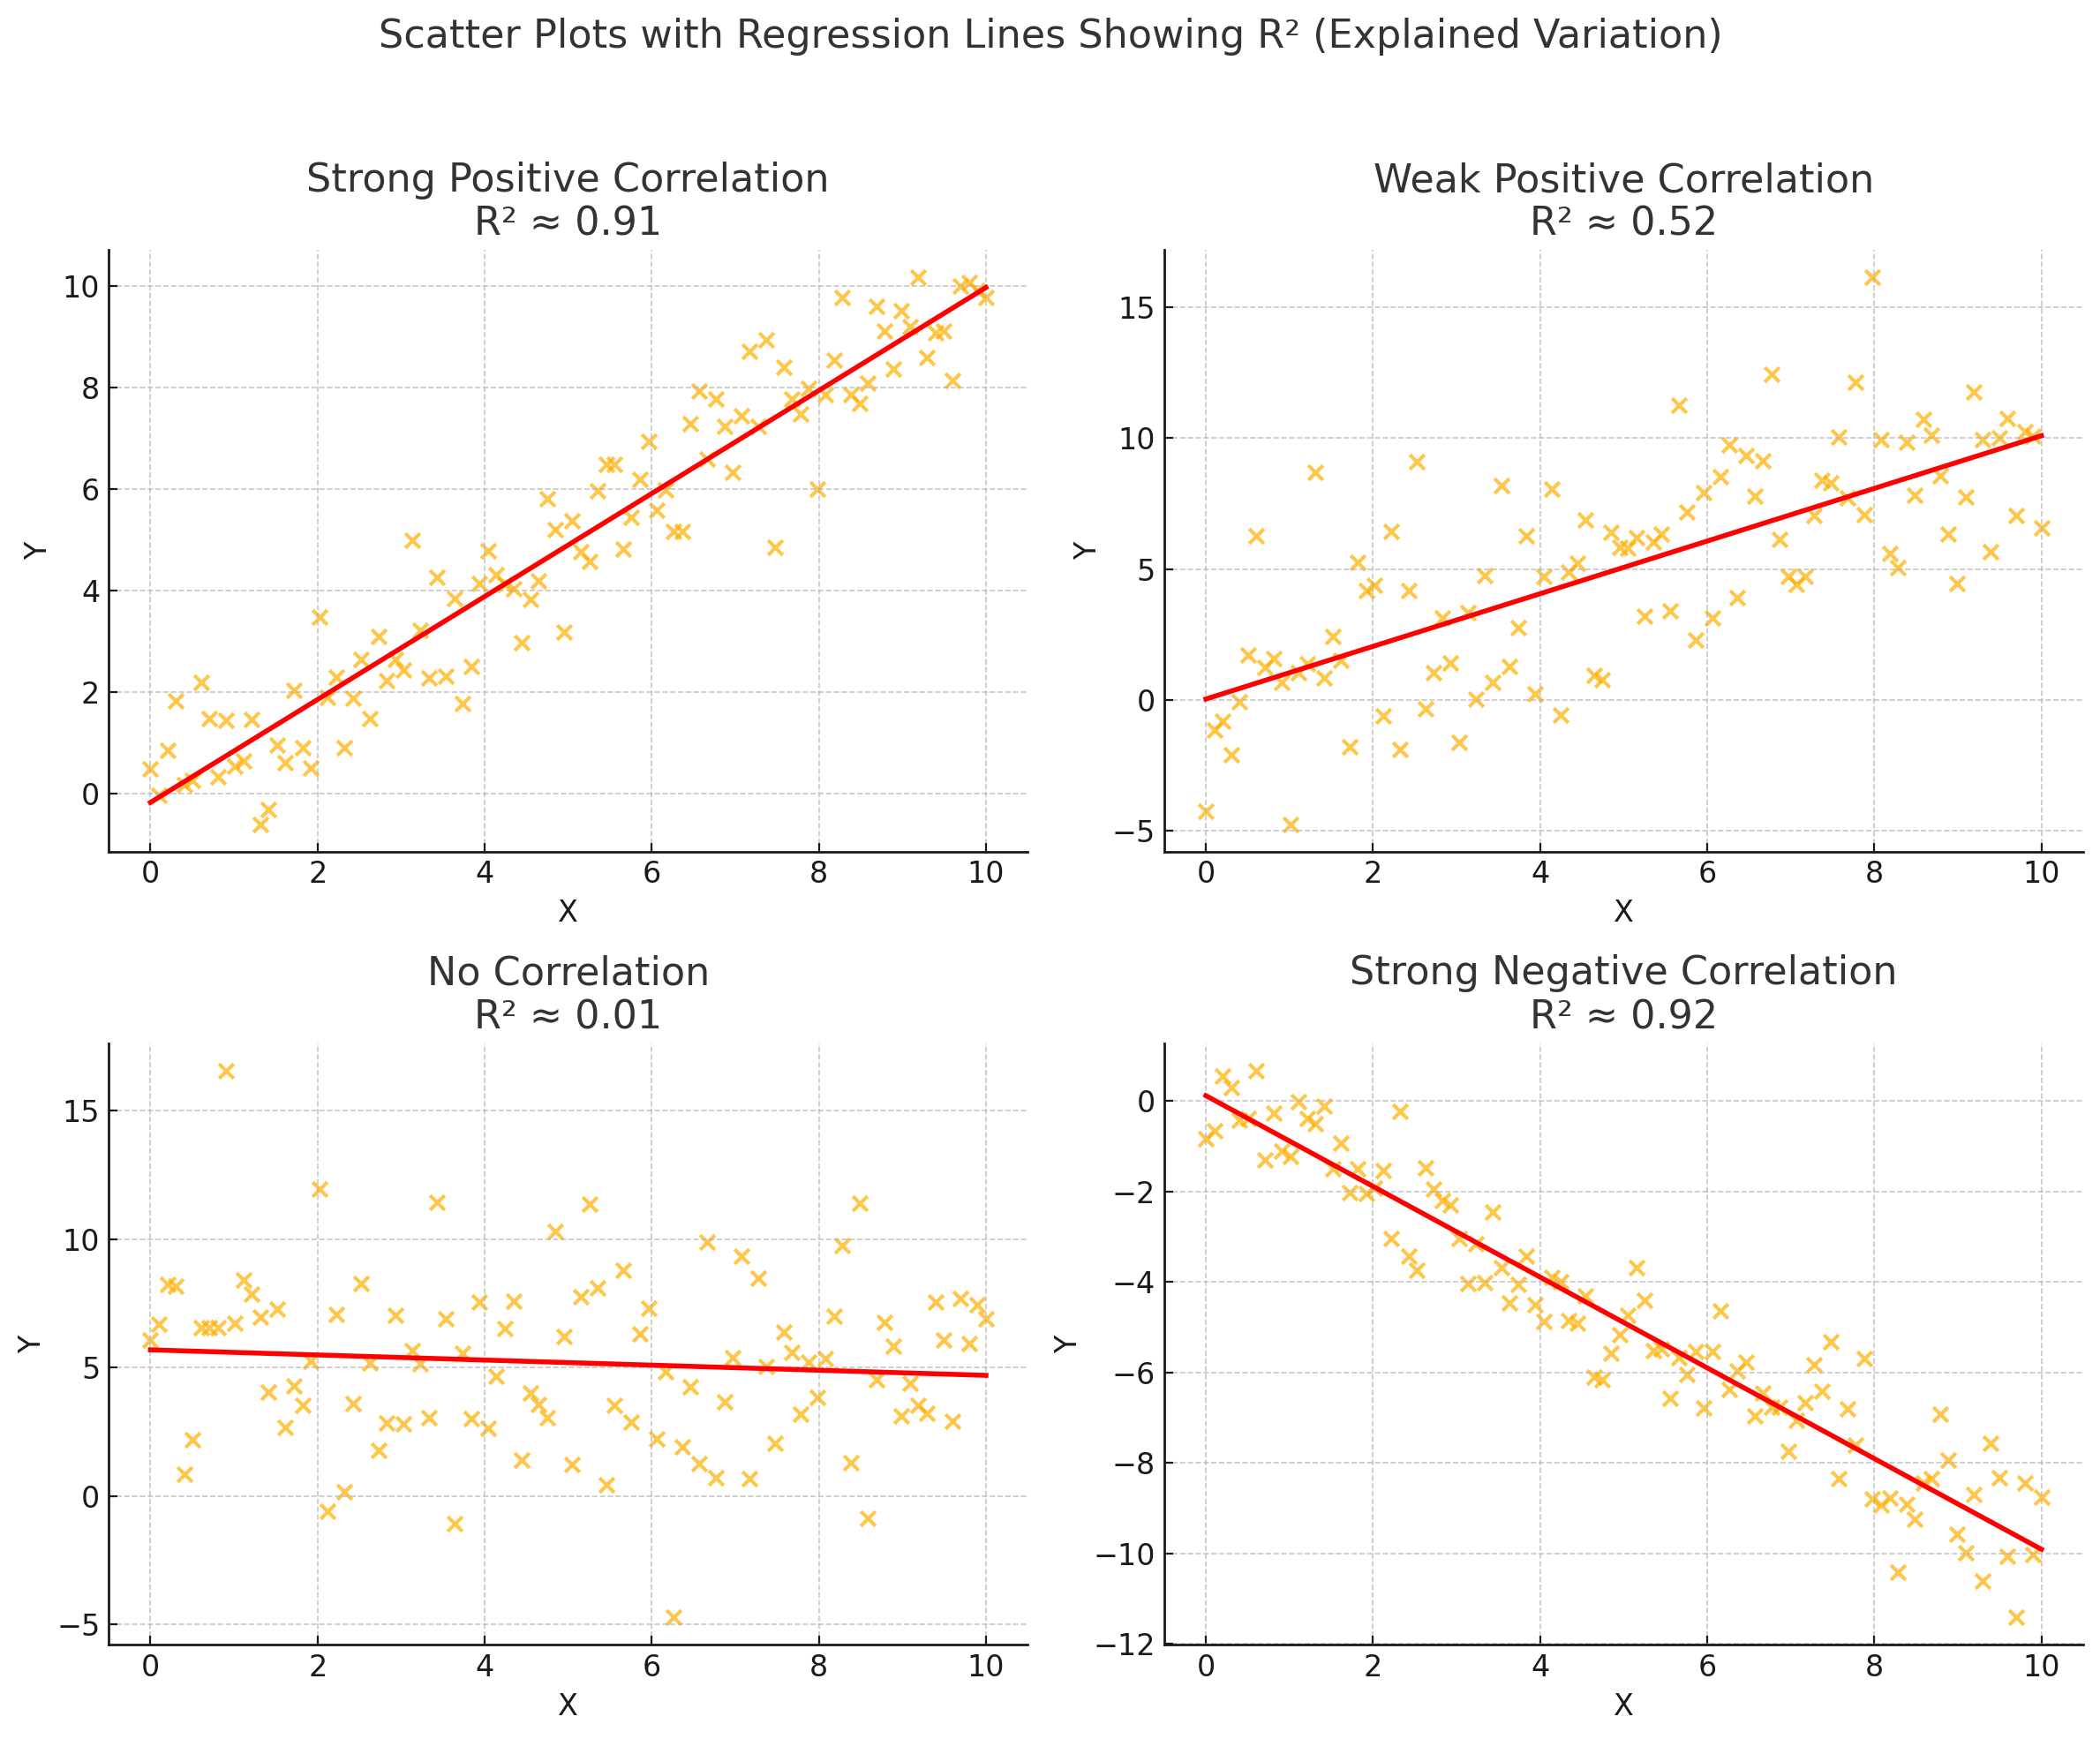

### **Standard Error**

In linear regression, the standard error helps measure how well the model fits the data. There are two main types of standard errors commonly used:


####**1. Standard Error of the Regression (Residual Standard Error)**

This measures the average distance that the observed values fall from the regression line. A smaller RSE means your model predictions are closer to actual values. It's measured in the same units as the response variable (y).


$SE_{\text{regression}} = \sqrt{ \frac{\sum (y_i - \widehat{y}_i)^2}{n - k - 1} }$

where,  
$y_i$ = observed values  
$\widehat{y}_i$ = predicted values  
$n$ = number of observations  
$k$ = number of independent variables

> **Note**  
> In statsmodels, the Root MSE (i.e., Residual Standard Error) does not automatically appear in ```.summary()``` for an OLS model like it does in R.

However, you can calculate it manually and even append it to the summary if you like.

In [8]:
print(model.summary())
print(f"\nRoot MSE (Residual Std Error): {np.sqrt(model.mse_resid):.4f}")

NameError: name 'model' is not defined

**Based on the Elmhurst dataset, the model prediction is off by about $\pm$\$4,782, on average. Remember, smaller RSE = better fit.**

**Exercise**

Compute the Residual Standard Error manually using Python and verify that it matches the RSE value calculated earlier.


####**2. Standard Error of the Coefficients**

These standard errors reflect how precisely each regression coefficient (slope, intercept) is estimated.

$y = \beta_0 + \beta_1 x + \varepsilon$  
where
- $\beta_0$ is the intercept (i.e., the expected value of y when x = 0).
- $\beta_1$ is the slope — it measures the change in y for a one-unit increase in x.

The standard error of $\beta_0$ tells us how precisely we have estimated the intercept.

$SE_{\beta_0} = s \cdot \sqrt{ \frac{1}{n} + \frac{\bar{x}^2}{\sum (x_i - \bar{x})^2} }$

where
- s = standard error of the residuals (RSE)
- n = number of observations
- $\bar{x}$ = mean of the independent variable
- $x_i$ = each observed value of the independent variable

$SE_{\beta_1} = \frac{s}{\sqrt{\sum (x_i - \bar{x})^2}}$  

where
- $s$ = standard error of the residuals (RSE)
- $\bar{x}$ = mean of the independent variable
- $x_i$ = predictor values

According to the model summary, the standard error of the intercept ($SE_{\beta_0}$) is 1.291. This means that when family income is zero, the predicted gift aid is \$24,000 with a margin of error of approximately $\pm$ \$1,291. The standard error of the slope ($SE_{\beta_1}$) is 0.011, indicating that for every \$1,000 increase in income, the gift aid is expected to decrease by \$43, with an uncertainty of $\pm$\$11.

**Confidence Interval of Regression coefficients**

A confidence interval (CI) gives you a range of plausible values for an unknown parameter (like a mean or a regression coefficient), based on your sample data.

A 95% confidence interval means that we are 95% confident that the true population value lies within this range.

For example, as per the model summary, the 95% confidence interval (corresponding to the 0.025 and 0.975 quantiles) for $\beta_0$ is [21.723, 26.916]. This means that if the study were repeated 100 times, approximately 95 of those intervals would contain the true value of $\beta_0$, which lies between \$21k and \$26k.

Similarly, the 95% confidence interval for $\beta_1$ is [-0.065, -0.021], indicating that for every \$1,000 increase in family income, the gift aid is expected to decrease by an amount between \$21 and \$65.


### **Hypothesis test**

A hypothesis test helps you answer: "Is the effect I'm seeing in the data real, or just due to random chance?"

1.	Null Hypothesis ($H_0$), $\beta_1 = 0$ (no relationship between x and y)
- Assumes no effect, no difference, or no relationship.
- Example: “The mean gift aid is the same regardless of income.”

2.	Alternative Hypothesis ($H_1$ or $H_a$), $\beta_1 \ne 0$ (there is a relationship)
- Claims there is an effect, difference, or relationship.
- Example: "Higher income is associated with lower gift aid."

> **Often, testing $\beta_0$ is less important unless the intercept has a real-world meaning (e.g., cost when quantity = 0).**

To test the null hypothesis, we assess whether our estimate of $\beta_1$ is far enough from zero to suggest a real effect. But how far is “far enough”? That depends on the standard error SE($\beta_1$) of $\beta_1$. If SE($\beta_1$) is small, even a modest value of $\beta_1$ can indicate strong evidence against the null hypothesis. However, if SE($\beta_1$) is large, $\beta_1$ must be much larger in absolute terms for us to confidently reject the null and conclude a relationship between X and Y.

### **t-test**
A t-test is the entire hypothesis testing procedure, which includes:
- stating $H_0$ and $H_1$
- computing the t-statistic (t-value)
- comparing it to a critical value or using a p-value
- making a decision (reject or fail to reject $H_0$)

In a t-test (including testing regression coefficients), there are two equivalent decision approaches:

1. Critical value approach
    - Compute the test statistic (t-value)
    - Compare it to the critical value from the t-distribution with df = n - k
    - Decision: reject $H_0$ if $|t| > t_{\text{critical}}$

2. p-value approach
    - Compute the p-value associated with the observed t
    - Compare it to the chosen significance level $\alpha$
    - Decision: reject $H_0$ if $p < \alpha$

These two methods will always lead to the same conclusion, provided:  
      - You are using the same $\alpha$    
      - You are conducting the same type of test (one-tailed vs two-tailed)  

## Critical value approach

### **t-statistics**

t-statistic (also called the t-score or t-value) is a value that tells you how many standard errors your sample statistic (like a sample mean or regression coefficient) is away from the null hypothesis value (usually 0).

For regression:

$t = \frac{\hat{\beta_i} - 0}{SE(\hat{\beta_i})}$

where:
- $\hat{\beta_i}$ = estimated coefficient for variable $i$
- $SE(\hat{\beta_i})$ = standard error of the coefficient
- Null hypothesis: $\beta_i$ = 0 (no effect)

**How to interpret t-statistics**

| **t-Statistic Value** | **Interpretation**                                           |
| --------------------- | ------------------------------------------------------------ |
| Close to 0            | The variable likely has **no significant effect** on the outcome. A t-statistic near 0 means your sample result is close to the null hypothesis|
| Large positive        | Strong **positive effect**; coefficient is significantly > 0. A large t-statistic (positive) means your result is far from what the null hypothesis predicts. |
| Large negative        | Strong **negative effect**; coefficient is significantly < 0. A large t-statistic (negative) means your result is far from what the null hypothesis predicts.
|

**How far from zero does the t-statistic need to be to confidently reject the null hypothesis?**

The t-statistic should be far enough from 0 (either positive or negative) that the result is unlikely due to random chance. The exact value depends on:
- Significance level ($\alpha$) — typically 0.05
- Degrees of freedom (based on sample size)

**What is a significance level?**
The significance level, denoted by α (alpha), is the threshold for deciding whether to reject the null hypothesis in a statistical test.

It’s the probability of rejecting the null hypothesis when it is actually true.
In other words, it’s the risk of a false positive (Type I error).

***Common significance level***

| **$α$ (Significance Level)** | **Confidence Level** | **Meaning**                  |
| -------------------------- | -------------------- | ---------------------------- |
| 0.05                       | 95%                  | 5% chance of false positive  |
| 0.01                       | 99%                  | 1% chance of false positive  |
| 0.10                       | 90%                  | 10% chance of false positive |

If you set α = 0.05, you’re saying: “I’m willing to accept a 5% chance of wrongly rejecting the null hypothesis.”

So in a t-test, you’ll:
- Reject $H_0$ if the p-value < 0.05 (in linear regression, $β_1\ne0$)
- Fail to reject $H_0$ if the p-value ≥ 0.05 ($β_1=0$)

**What is a degree of freedom?**
A degree of freedom (df) is the number of independent values that can vary in an analysis without breaking a constraint. In other words, degrees of freedom generally refer to the number of values in a calculation that are free to vary.

It’s a key concept in many statistical tests like t-tests, ANOVA, and regression. Think of it as the number of values that are “free to vary” when computing a statistic.

Imagine you have 3 numbers that must add up to 100.
- If you choose two of them freely (say, 30 and 40), the third must be 30 to make the total 100.
- Only 2 values were free to vary; the third was constrained by the total.

Degrees of freedom = 2

In statistics, you often lose one or more degrees of freedom when estimating parameters from your data. Degrees of freedom adjust for this loss, giving a more honest picture of variability.

In linear regression, $df = n - k$, where
- n = number of observations
- k = number of estimated parameters; for 1 predictor, k is 2 (intercept $\beta_0$ and slope $\beta_1$)

**Remember** 	A predictor (or independent variable) is an input variable, e.g., $x_1$, $x_2$.
A parameter is a coefficient you estimate from the data, e.g., $\beta_0$, $\beta_1$, $\beta_2$.

In the Elmhurst dataset, there are 50 observations with a linear regression with 1 predictor would be 48 (df = 50 - 2); k = 2 (one for the intercept and one for the slope).


**How much $n$ has to be?**  

There isn’t a single fixed value of n that is "correct" for linear regression—the required sample size depends on what you want to achieve (estimation accuracy, hypothesis testing, prediction) and how complex your model is. However, there are well-established guidelines and principles.

First, from a mathematical feasibility standpoint, you must have $n > k$, otherwise the model cannot be estimated (you would have zero or negative residual degrees of freedom). In practice, just satisfying $n > k$ is far from sufficient.

A more meaningful way to think about it is through residual degrees of freedom:

df = n - k

You want this value to be reasonably large so that your estimates of variance (and hence t-tests, confidence intervals) are stable.

In applied statistics, several rules of thumb are commonly used:
- Minimum baseline: $n \ge 10k$
This ensures at least 10 observations per parameter.
- More reliable inference: $n \ge 20k$
This gives more stable coefficient estimates and hypothesis tests.
- High-quality modeling (especially for teaching or publication): $n \ge 30k$ or more



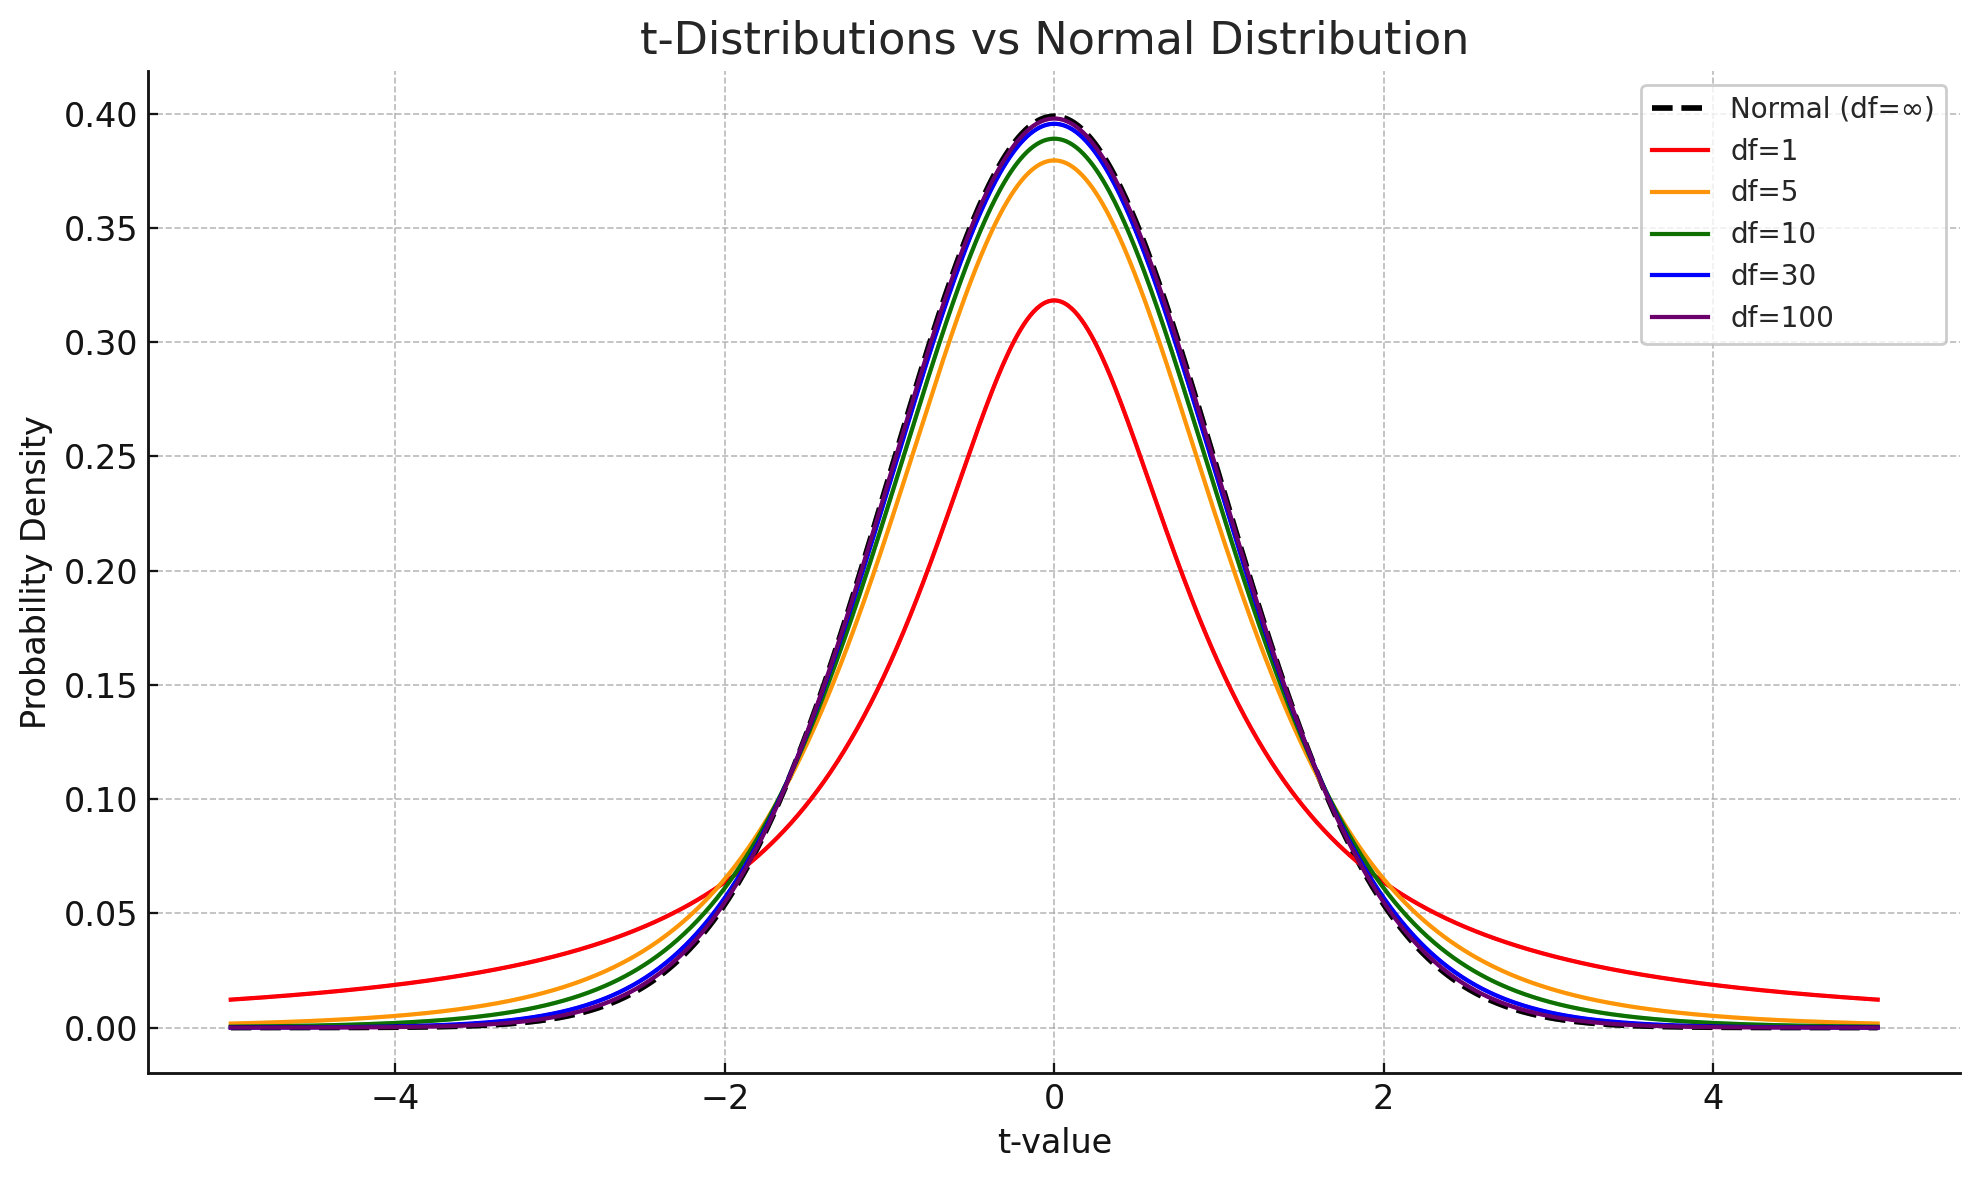

The above plot is an example, and does not reflect the Elmhurst dataset.
The plot compares t-distributions with different degrees of freedom (df) to the standard normal distribution (black dashed line):
- Red (df = 1): Very wide, heavy tails — a lot of uncertainty.
- Orange to Blue (df = 5 to 30): Becomes narrower, more peaked.
- Purple (df = 100): Almost identical to the normal distribution.

As df increases, the t-distribution approaches the normal distribution. This reflects increased confidence and precision with larger samples or simpler models.

**If degrees of freedom aren’t in the t-value formula, how exactly do they affect the outcome?**

The formula to calculate t-statistics does not directly include degrees of freedom (df), but dfs are essential in calculating and interpreting the t-value in hypothesis testing. You use the t-distribution to interpret the t-value — and the shape of that distribution depends on the degrees of freedom.

For example, if $t$ = 2.1:
- With df = 10, p-value ≈ 0.05 → Not significant at 0.05 level
- With df = 50, p-value ≈ 0.04 → Statistically significant

Same t-value, different conclusions depending on df!


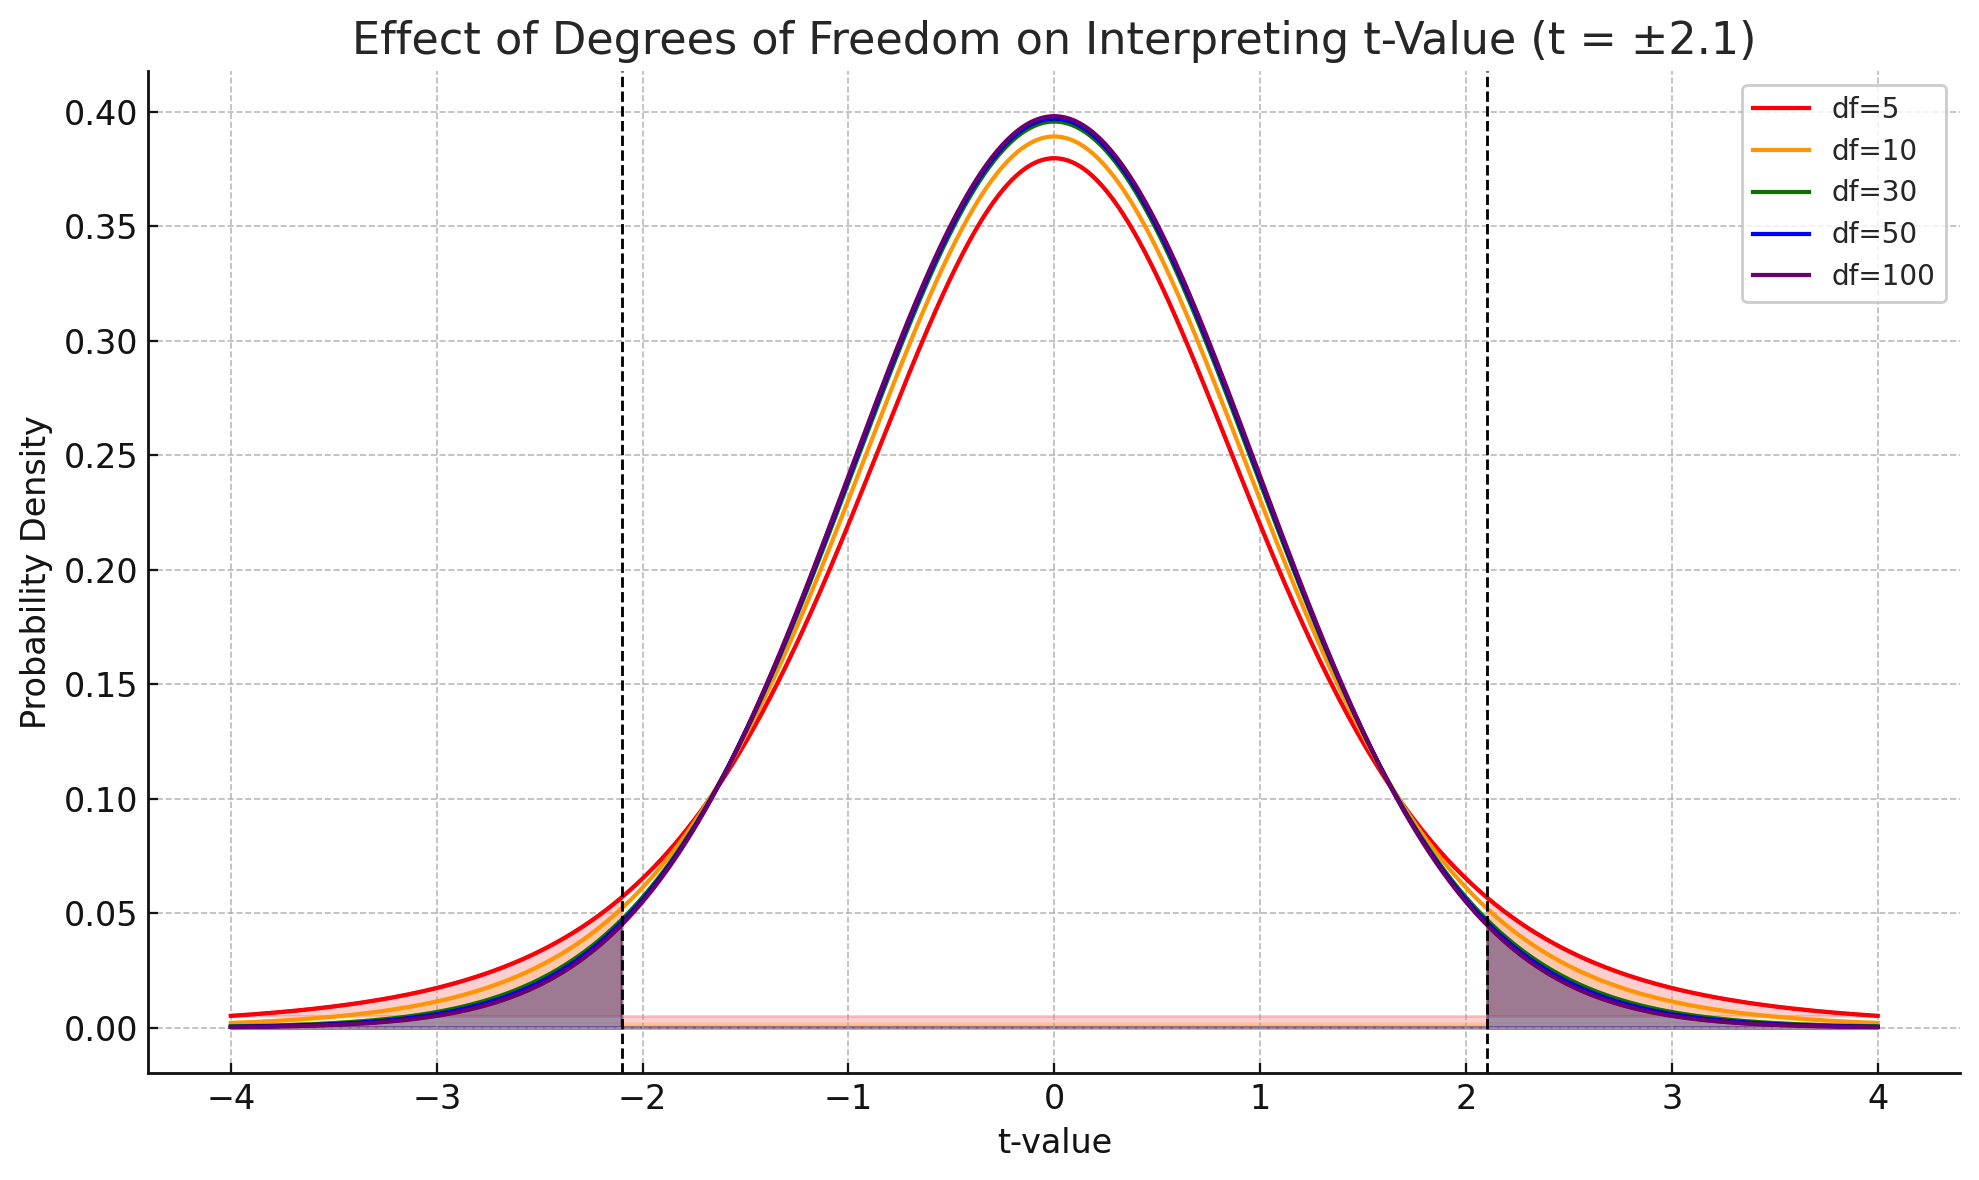

This plot shows t-distributions with different degrees of freedom and highlights the rejection regions (shaded) for a two-tailed test at t = ±2.1:
- Lower df (red/orange): Wider, heavier tails → t = 2.1 less extreme, harder to reject the null.
- Higher df (blue/purple): Narrower distribution → t = 2.1 more extreme, easier to reject the null.

The table below gives corresponding p-value at $t = 2.1$.


| **Degrees of Freedom (df)** | **p-value (two-tailed, t = 2.1)** |
| --------------------------- | --------------------------------- |
| 5                           | 0.0898                            |
| 10                          | 0.0621                            |
| 30                          | 0.0442                            |
| 50                          | 0.0408                            |
| 100                         | 0.0382                            |

- Same t-value (2.1) → different p-values depending on degrees of freedom.
- As df increases, the shaded area (p-value) decreases → result becomes more significant.
- At df = 5, p = 0.0898 → Not statistically significant at the 0.05 level.
- At df ≥ 30, p < 0.05 → You can reject the null hypothesis.

**The original question was, "How far from zero does the t-statistic need to be to confidently reject the null hypothesis?"**

The question is implicitly a two-tailed question. Because the phrase "how far from zero" does not specify a direction—it cares about magnitude, not whether the value is positive or negative.

**How large must $|t|$ be (in either direction) to reject $H_0$?**

So the decision rule becomes:

$|t| > t_{\text{critical}}$

Based on the standard t-distribution table (often called a t-table), critical values of the t-statistic can be determined given the significance level $\alpha$, the degrees of freedom, and whether the test is one-tailed or two-tailed.


Based on the Elmhurst dataset, where df=48, $\alpha$ = 0.05 and the test is two-tailed. The $t_{\text{critical}} \approx 2.01$.

$|t| = 3.9 > 2.01$, Reject $H_0$

Even at a stricter level:  
 - For $\alpha = 0.01$, $t_{\text{critical}} \approx 2.68$

Since:
3.9 > 2.68

You would still reject $H_0$



### **p-value**

**Definition**
The p-value provides the evidence against the null hypothesis; a small p-value provides evidence against the null hypothesis and suggests that the predictor is significantly associated with the response variable.

You can obtain the p-values for regression coefficients directly from the model output using model.summary().
Reject the null hypothesis if the p-value is less than the chosen significance level (commonly 0.05)


## **Residual plot to visually check model fitness**

A residual plot is a diagnostic tool used in regression analysis to assess how well a model fits the data. A residual is the difference between the actual value and the predicted value from a regression model:

$\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}$

**What does a residual plot show?**

A residual plot typically has:
- X-axis: Predicted values (or sometimes the independent variable)
- Y-axis: Residuals

It shows how far off the model’s predictions are, for each observation.

**Ideal residual plot (good model):**
Residuals are randomly scattered around zero (no pattern) indicates that:
- The model is unbiased
- A linear relationship exists
- Homoscedasticity (constant variance of errors) ????

**Bad residual plot (model problems):**
- Curved pattern: Your model may be missing a non-linear relationship
- Fan shape or cone: Suggests heteroscedasticity (non-constant error variance)
- Clusters or gaps: Possible missing variables or outliers

In [ ]:
import statsmodels.formula.api as smf
model = smf.ols('gift_aid ~ family_income',data=df_elmhurst).fit()
df_elmhurst["residuals"] = model.resid
df_elmhurst["fitted"] = model.fittedvalues  #fitted value is the same as predicted value
RSS = sum(df_elmhurst["residuals"] ** 2)
print(model.summary())
print(f"\nRSS (Residual Sum of Squares): {RSS:.2f}")
print(f"Root MSE (Residual Std Error): {np.sqrt(model.mse_resid):.4f}")


                            OLS Regression Results                            
Dep. Variable:               gift_aid   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     15.88
Date:                Thu, 07 May 2026   Prob (F-statistic):           0.000229
Time:                        18:35:03   Log-Likelihood:                -148.18
No. Observations:                  50   AIC:                             300.4
Df Residuals:                      48   BIC:                             304.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        24.3193      1.291     18.831

**RSS**  
The Residual Sum of Squares (RSS) is a statistical measure used in regression analysis to quantify the total prediction error produced by a regression model. It represents the overall discrepancy between the observed values and the values predicted by the model. A smaller RSS indicates that the regression model fits the data more closely, whereas a larger RSS suggests greater disagreement between the observed and predicted values. In linear regression, the primary objective of the fitting process is to determine the model parameters that minimize the RSS, thereby producing the best-fitting regression line for the given dataset.

- RSS tells you the total error energy in the model.
- RSE tells you how wrong predictions are on average.

In most practical situations, RSE is more interpretable and useful than RSS.

Researchers and practitioners usually prefer RSE because it is in the same units as the response variable.

However, RSS is still important because:

**Optimization**
- Linear regression algorithms minimize RSS.
- The “best fit” regression line is the one with the smallest RSS.

**Foundation for Other Metrics**
- RSE, $R^2$, adjusted $R^2$, F-statistics, and variance estimates all depend on RSS.

**Model Comparison**
- When comparing models on the same dataset, lower RSS generally indicates a better fit.


In [ ]:
fig = px.scatter(df_elmhurst, x='fitted', y='residuals',
                 title='Residuals vs Fitted (Predicted) Values - Gift aid on family income',
                 labels={'fitted': 'Fitted Values', 'residuals': 'Residuals'},
                 hover_data=['family_income', 'gift_aid'])

fig.add_hline(y=0, line_color='red')

fig.show()

**Homoscedasticity gives reliability to the statistical conclusions of a regression model.**

When the residual variance remains roughly constant:
- standard errors are estimated properly,
- p-values become more trustworthy,
- confidence intervals are more accurate,
- hypothesis tests become more valid.

In other words, homoscedasticity helps ensure that the regression model’s statistical inference is dependable.

Suppose you are predicting house prices using square footage.

| **SqFt** | **Actual Price** | **Predicted Price** | **Residual** |
| -------- | ---------------- | ------------------- | ------------ |
| 1200     | 520k             | 500k                | +20k         |
| 1500     | 610k             | 590k                | +20k         |
| 1800     | 700k             | 730k                | -30k         |
| 2200     | 850k             | 820k                | +30k         |
| 2600     | 980k             | 1.01M               | -30k         |

- residuals stay roughly within ±20k–30k,
- spread is fairly constant.

This is homoscedasticity.

The model's uncertainty is relatively stable across all house sizes.

**Example of Heteroscedasticity**
| **SqFt** | **Actual Price** | **Predicted Price** | **Residual** |
| -------- | ---------------- | ------------------- | ------------ |
| 1200     | 520k             | 510k                | +10k         |
| 1500     | 610k             | 600k                | +10k         |
| 1800     | 720k             | 710k                | +10k         |
| 3500     | 2.1M             | 1.7M                | +400k        |
| 5000     | 4.0M             | 3.1M                | +900k        |

- smaller homes have tiny errors,
- expensive homes have massive errors.

The residual spread grows as fitted values increase.

This is **heteroscedasticity**.

A residual plot would often show a funnel shape:
- narrow on the left,
- wide on the right.

That tells you the variance of errors is not constant.

### **Q-Q Plot → Checking Normality**

A Q-Q plot is a diagnostic tool used to determine whether data (often residuals) approximately follows a normal distribution.

It does not change the data.

It only helps you assess whether the following assumption is reasonable:

$\epsilon \sim N(0,\sigma^2)$

This means:
- residuals ($\epsilon$) are approximately normally distributed,
- with mean 0,
- and variance $\sigma^2$.

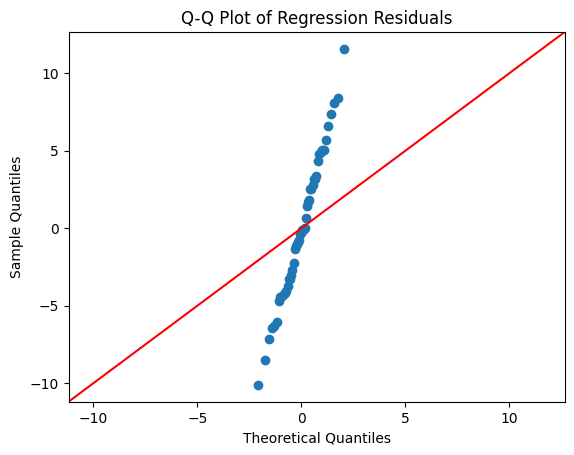

In [ ]:
sm.qqplot(df_elmhurst["residuals"], line='45')
plt.title("Q-Q Plot of Regression Residuals")
plt.show()

The following Q-Q plot is done using plotly. The same outcome, however less number of lines using matplotlib package.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
import plotly.graph_objects as go
import plotly.express as px

theoretical_quants = np.sort(stats.norm.ppf(np.linspace(0.01, 0.99, len(df_elmhurst["residuals"]))))
sample_quants = np.sort(df_elmhurst["residuals"])

qq_fig = go.Figure()
qq_fig.add_trace(go.Scatter(x=theoretical_quants, y=sample_quants,
                            mode='markers', name='Residuals'))
qq_fig.add_trace(go.Scatter(x=theoretical_quants, y=theoretical_quants,
                            mode='lines', name='45° Line'))
qq_fig.update_layout(title='Q-Q Plot of Residuals (Plotly)',
                     xaxis_title='Theoretical Quantiles (Normal)',
                     yaxis_title='Sample Quantiles (Residuals)',
                     width=600, height=500)

# 2. Histogram of residuals
hist_fig = px.histogram(df_elmhurst["residuals"], nbins=20, marginal="violin", opacity=0.7,
                        title='Histogram of Residuals (Plotly)')
hist_fig.update_layout(xaxis_title='Residuals', yaxis_title='Count',
                       width=600, height=500)

# Show both
qq_fig.show()
hist_fig.show()

## **Identifying outliers**

Identifying outliers in regression is crucial for building reliable models. There are several methods used, each targeting different aspects of what makes a point an outlier (large error, high leverage, or strong influence). In regression models, studentized residuals are among the most commonly used method in regression models to identify outliers — especially Y-outliers


### **Box plot**

A box plot is an important statistical visualization tool used to summarize the distribution of a dataset. It provides a concise graphical representation of the median, quartiles, spread, and potential outliers within the data. By displaying the interquartile range (IQR), a box plot helps analysts understand the variability and central tendency of the dataset without being overly influenced by extreme values. It is particularly useful for identifying skewness, detecting unusual observations, and comparing distributions across multiple groups or categories. Unlike simple averages, box plots reveal how data are spread and whether the distribution is symmetric or skewed. Consequently, box plots play a significant role in exploratory data analysis (EDA), quality control, and statistical interpretation.

In [ ]:
fig = px.box(
    df_elmhurst,
    x = "family_income",
    points = "all",
    title = "Family income in k"
)
fig.show()

**Outlier identification using boxplot**

Outliers in a box plot are identified using the interquartile range (IQR), which measures the spread of the middle 50% of the data. The process begins by calculating the first quartile (Q_1) and the third quartile (Q_3). The interquartile range is then determined as:

$IQR = Q_3 - Q_1$

Using the IQR, lower and upper fences are calculated to define the acceptable range of values:

$\text{Lower Fence} = Q_1 - 1.5 \times IQR$

$\text{Upper Fence} = Q_3 + 1.5 \times IQR$

Any data point lying below the lower fence or above the upper fence is considered a potential outlier. In the box plot, these observations are typically displayed as individual points beyond the whiskers. The whiskers themselves extend only to the smallest and largest values that fall within the fence boundaries. This method helps identify unusually distant observations that may represent measurement errors, rare events, or significant deviations from the overall distribution.

> An outlier simply refers to a data point that is unusually far from the rest of the observations. It is a statistical indication that the value is uncommon relative to the overall distribution.

For example, a box plot flags observations beyond the fences as potential outliers, but this does not automatically imply the value is incorrect.

### **Studentized residual - identifying response (Y) outliers**

A studentized residual is a standardized form of a residual in regression analysis, adjusted to account for variability in the data and leverage. It helps identify outliers or influential points more accurately than regular residuals.

>**Note: Studentized residual is also called externally studentized residual**

A studentized residual is the residual divided by an estimate of its standard deviation, making it easier to compare across observations:

$r_i^* = \frac{e_i}{\widehat{\sigma}{(i)} \sqrt{1 - h{ii}}}$

Where:
- $e_i$ = residual for the i-th observation
- $\widehat{\sigma}_{(i)}$ = estimated standard deviation excluding the i-th observation (i.e., leave-one-out)
- $h_{ii}$ = leverage of the i-th observation (diagonal of the hat matrix)

**Why studentized residuals are widely used for outlier detection**

- Accounts for leverage: Points far from the average of the predictors can have small residuals but still exert large influence. Studentization corrects for that.
- Outlier detection: Values of studentized residuals greater than ±2 (or especially ±3) can suggest outliers. Usually > |2| (for small samples) or > |3| (for larger samples).

In regression and outlier diagnostics, a common practical interpretation is:

| **Sample Size (**n**)**   | **Informal Interpretation** |
| ------------------------- | --------------------------- |
| $n < 30$                  | Small sample                |
| $30 \le n < 100$          | Moderate sample             |
| $n \ge 100$               | Large sample                |


- Better than raw residuals: Because it adjusts for unequal variance (heteroscedasticity) and leverage.

**While studentized residuals are great for detecting Y-outliers**,
- Detect X-outliers (extreme predictor values) — that’s where leverage and Mahalanobis distance come in.
- Identify influential points — which is better handled by Cook’s Distance, DFFITS, and DFBETAS.

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

# Fit the model
model = smf.ols('gift_aid ~ family_income',data=df_elmhurst).fit()

# Get influence measures
influence = OLSInfluence(model)

# Studentized residuals (externally studentized)
studentized_residuals = influence.resid_studentized_external

# Add to DataFrame
df_elmhurst['Studentized_Residual'] = studentized_residuals

# Flag outliers
df_elmhurst['Outlier'] = df_elmhurst['Studentized_Residual'].abs() > 3

In [ ]:
fig = px.scatter(
    df_elmhurst,
    x='fitted',
    y='Studentized_Residual',
    color='Outlier',
    color_discrete_map={True: 'red', False: 'blue'},
    title="Studentized Residuals vs Fitted Values",
    labels={'fitted': 'Fitted value', 'Studentized_Residual': 'Studentized Residual'}
)

# Add horizontal reference lines at ±3
fig.add_shape(type='line', x0=df_elmhurst['fitted'].min(), x1=df_elmhurst['fitted'].max(), y0=3, y1=3,
              line=dict(color='red', dash='dash'))
fig.add_shape(type='line', x0=df_elmhurst['fitted'].min(), x1=df_elmhurst['fitted'].max(), y0=-3, y1=-3,
              line=dict(color='red', dash='dash'))

fig.update_layout(template='plotly_white')
fig.show()

Based on the studentized residual plot above, the model does not exhibit any response (Y) outliers.

### **Cook's distance**

Cook’s distance is a diagnostic statistic that measures how much a regression model’s predictions change if you remove a particular observation.

Think of it as:

> “If I delete this data point, how much would my regression equation (and predictions) change?”


**Formula (conceptual)**

For observation i:

$D_i = \frac{\text{Sum of squared changes in predicted values (if \(i\) removed)}}{\text{Number of predictors} \times \text{Mean Squared Error}}$

In a more regression-specific form:

$D_i = \frac{(r_i^2)}{p \cdot \text{MSE}} \cdot \frac{h_{ii}}{(1-h_{ii})^2}$

Where:
- $r_i$ = studentized residual for observation i (tells you how unusual its response is)
- $h_{ii}$ = leverage of observation i (tells you how unusual its predictors are)
- $p$ = number of parameters (including intercept)
- $MSE$ = mean squared error of the model

This combination means Cook’s distance looks at both response outliers (via residuals) and predictor outliers (via leverage).

**Interpretation**
- Small D_i → Removing the point doesn’t change the model much → Not influential.
- Large D_i → Removing the point changes predictions a lot → Influential point.

A common rule of thumb:
- $D_i$ > 1 → Potentially influential (strict, check further)
- Some use $D_i > 4/n$ for large datasets - lenient

**Note**
- Points with high leverage alone may not distort your model if their Y values fit the model well.
- Points with large residuals alone may not be influential if their X values are typical.
- Cook’s distance catches the dangerous combo: unusual X and unusual Y → high influence.


In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

# Fit the model
model = smf.ols('gift_aid ~ family_income',data=df_elmhurst).fit()

# Get influence measures
influence = OLSInfluence(model)

# Cook's distance
cooks_d, p_values = influence.cooks_distance

# Display results
for i, (d, p) in enumerate(zip(cooks_d, p_values), start=1):
    print(f"Observation {i}: Cook's D = {d:.4f}, p-value = {p:.4f}")

Observation 1: Cook's D = 0.0009, p-value = 0.9991
Observation 2: Cook's D = 0.0185, p-value = 0.9817
Observation 3: Cook's D = 0.0245, p-value = 0.9758
Observation 4: Cook's D = 0.0202, p-value = 0.9801
Observation 5: Cook's D = 0.0001, p-value = 0.9999
Observation 6: Cook's D = 0.0114, p-value = 0.9887
Observation 7: Cook's D = 0.0195, p-value = 0.9807
Observation 8: Cook's D = 0.0168, p-value = 0.9833
Observation 9: Cook's D = 0.0037, p-value = 0.9963
Observation 10: Cook's D = 0.0043, p-value = 0.9957
Observation 11: Cook's D = 0.0017, p-value = 0.9983
Observation 12: Cook's D = 0.0170, p-value = 0.9831
Observation 13: Cook's D = 0.0019, p-value = 0.9981
Observation 14: Cook's D = 0.0381, p-value = 0.9627
Observation 15: Cook's D = 0.0112, p-value = 0.9889
Observation 16: Cook's D = 0.0739, p-value = 0.9289
Observation 17: Cook's D = 0.1532, p-value = 0.8584
Observation 18: Cook's D = 0.0093, p-value = 0.9907
Observation 19: Cook's D = 0.2901, p-value = 0.7495
Observation 20: Cook'

In [ ]:
# Put into a DataFrame
cd_df = pd.DataFrame({
    "obs": np.arange(len(df_elmhurst)) + 1,
    "cooks_d": cooks_d,
    "pval": p_values
})
thr_1 = 1
thr_4n = 4/len(df_elmhurst)
cd_df["flag_D>1"] = cd_df["cooks_d"] > thr_1
cd_df["flag_D>4/n"] = cd_df["cooks_d"] > thr_4n

# --- Plotly visualization ---
fig = px.bar(
    cd_df, x="obs", y="cooks_d",
    hover_data={"obs": True, "cooks_d":":.4f", "pval":":.3f", "flag_D>1":True, "flag_D>4/n":True},
    title="Cook's Distance by Observation"
)

# horizontal reference lines
fig.add_hline(y=thr_1, line_dash="dash", annotation_text="D = 1", annotation_position="top left")
fig.add_hline(y=thr_4n, line_dash="dot", annotation_text=f"D = 4/n (n={len(df_elmhurst)})", annotation_position="bottom left")

# optional: visually emphasize bars above D=1
fig.update_traces(marker_color=np.where(cd_df["flag_D>1"], "crimson", "blue"))

fig.update_layout(xaxis_title="Observation index", yaxis_title="Cook's distance")
fig.show()


**Top ten most influential observations**

In [ ]:
# Top ten influential observations
cd_df.sort_values("cooks_d", ascending=False).head(10)

,obs,cooks_d,pval,flag_D>1,flag_D>4/n
18,19,0.290056,0.749524,False,True
21,22,0.158722,0.853680,False,True
16,17,0.153167,0.858404,False,True
15,16,0.073917,0.928854,False,False
40,41,0.061868,0.940082,False,False
46,47,0.059168,0.942617,False,False
33,34,0.046764,0.954356,False,False
25,26,0.042631,0.958302,False,False
13,14,0.038063,0.962682,False,False
2,3,0.024491,0.975818,False,False


#### **Residuals vs Leverage with Cook’s Distance**

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

# Fit the model
model = smf.ols('gift_aid ~ family_income',data=df_elmhurst).fit()

# Get influence measures
influence = OLSInfluence(model)
leverage = influence.hat_matrix_diag
stud_resid = influence.resid_studentized_external
cooks_d = influence.cooks_distance[0]
fitted = model.fittedvalues
p = model.normalized_cov_params.shape[0]
n = int(model.nobs)

In [ ]:
# Rules-of-thumb thresholds
lev_thr = 2 * p / n          # leverage guideline
r_thr = 2                    # studentized residual guideline
cd_thr1 = 1                  # strict
cd_thr4n = 4 / n             # lenient

# Combine in a DataFrame for plotting / inspection
out = pd.DataFrame({
    "obs": np.arange(n) + 1,
    "leverage": leverage,
    "stud_resid": stud_resid,
    "cooks_d": cooks_d,
    "fitted": fitted,
})
out["flag_cook_1"] = out["cooks_d"] > cd_thr1
out["flag_cook_4n"] = out["cooks_d"] > cd_thr4n


In [ ]:
fig = px.scatter(
    out, x="leverage", y="stud_resid",
    size="cooks_d", size_max=40,
    hover_data={
        "obs": True, "leverage":":.3f", "stud_resid":":.3f",
        "cooks_d":":.4f", "fitted":":.3f", "flag_cook_1":True, "flag_cook_4n":True
    },
    title="Residuals vs. Leverage (bubble size = Cook's Distance)"
)

# Reference lines: residual ±2, leverage 2p/n
fig.add_hline(y=r_thr,  line_dash="dash", annotation_text="Studentized resid = +2", annotation_position="top right")
fig.add_hline(y=-r_thr, line_dash="dash", annotation_text="Studentized resid = -2", annotation_position="bottom right")
fig.add_vline(x=lev_thr, line_dash="dot",  annotation_text=f"Leverage ≈ 2p/n (p={p}, n={n})", annotation_position="top left")

# Optional: faint note about Cook's D rules
fig.update_layout(
    xaxis_title="Leverage (hat values)",
    yaxis_title="Studentized residual",
    legend_title_text="",
    annotations=list(fig.layout.annotations) + [
        dict(
            xref="paper", yref="paper", x=0.99, y=0.02, showarrow=False,
            text=f"Cook's D guidelines: D>1 (strict), D>4/n≈{cd_thr4n:.3f} (lenient)"
        )
    ]
)

fig.show()

- Points far right (high leverage) or far up/down (|studentized residual| > 2) are suspicious.

- Big bubbles (high Cook’s D) are influential: removing them would noticeably change the fit.

- Check flagged rows for data issues, missing terms/transformations, or genuine but influential cases.

#### **What is leverage?**

In regression, leverage measures how far an observation’s predictor values (X) are from the average of all predictor values.

**Interpretation**

- High leverage = observation has unusual X-values (far from the predictor mean).
- Low leverage = observation has typical X-values.

Average leverage:
$\bar{h} = \frac{p}{n}$

where p = number of predictors (including intercept), n = sample size.
A common rule of thumb:
- $h_{ii} > \frac{2p}{n}$ → high leverage
- $h_{ii} > \frac{3p}{n}$ → very high leverage

####**Difference between studentized residual and Cook's distance**

**Studentized residual**

**Definition**
Residual divided by its estimated standard deviation (computed without using that observation’s error variance).

**Purpose**
Detect response (Y) outliers.

**Interpretation**
- |studentized residual| > 2 (sometimes > 3) → unusual Y-value given the model.
- Limitation: Does not consider whether the predictors (X) are extreme.

**Cook's distance**

**Definition**
Measures how much the fitted regression model (coefficients and predictions) would change if observation i were removed.

**Purpose**
Detect influential points (observations that can distort regression results).

**Interpretation**
- $D_i > 1$ (strict rule) → influential
- $D_i > 4/n$ (lenient rule) → influential in large datasets
- Key feature: Combines residual size (outlier in Y) + leverage (outlier in X).

**Summary**

| **Measure**              | **Focus**       | **Detects**                  | **Uses Leverage?** | **Typical Cutoff** |
| ------------------------ | --------------- | ---------------------------- | ------------------ | ------------------ |
| **Studentized Residual** | Response side   | Outliers in Y                | ❌ No               |                    |
| **Cook’s Distance**      | Model influence | Points that change model fit | ✅ Yes              | D > 1 or D > 4/n   |



**In short**
- Studentized residual: “Is this Y unusual given the model?”
- Cook’s distance: “Would my regression change a lot if I dropped this point?”

**Why it matters**
- A high-leverage point with a small residual → fits the line well, not a problem.
- A high-leverage point with a large residual → can pull the regression line and distort results (influential point).
- That’s why Cook’s distance combines leverage + residual.